In [14]:
import warnings
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

warnings.filterwarnings("ignore")

# ── Aesthetic constants ───────────────────────────────────────────────────────
BG   = "#f6f1eb"
DARK = "#2f241f"
EDGE = "#3d3128"
GRID = "#8b6f5a"

DOMAIN_COLORS = {
    "EWT":   "#EFA6C1",
    "CONLL": "#8FD3B6",
    "WIESP": "#F4B183",
}

EXPNAME_TO_DOMAIN = {
    "baseline_ewt_only":   "EWT",
    "baseline_conll_only": "CONLL",
    "baseline_astro_only": "WIESP",
}

EVALSET_TO_DOMAIN = {
    "ewt_dev":    "EWT",
    "conll_test": "CONLL",
    "astro_test": "WIESP",
}

EXPNAME_LABELS = {
    "baseline_ewt_only":   "EWT Only",
    "baseline_conll_only": "CoNLL Only",
    "baseline_astro_only": "WIESP Only",
}

EVALSET_LABELS = {
    "ewt_dev":    "EWT Dev",
    "conll_test": "CoNLL Test",
    "astro_test": "WIESP Test",
}

EXPNAME_TO_DIR = {
    "baseline_ewt_only":   "ewt_only",
    "baseline_conll_only": "conll_only",
    "baseline_astro_only": "astro_only",
}

BASELINES_ORDER = ["baseline_ewt_only", "baseline_conll_only", "baseline_astro_only"]
EVALSETS_ORDER  = ["ewt_dev", "conll_test", "astro_test"]

F1_COL        = "entity_f1_micro"
PRECISION_COL = "entity_precision"
RECALL_COL    = "entity_recall"

plt.rcParams.update({
    "font.family":       "DejaVu Serif",
    "axes.facecolor":    BG,
    "figure.facecolor":  BG,
    "axes.edgecolor":    EDGE,
    "axes.linewidth":    0.8,
    "text.color":        DARK,
    "axes.labelcolor":   DARK,
    "xtick.color":       DARK,
    "ytick.color":       DARK,
    "axes.grid":         False,
    "axes.spines.top":   False,
    "axes.spines.right": False,
})

# ── Paths ─────────────────────────────────────────────────────────────────────
RUNS_DIR      = Path("runs")
ITER_CONLL    = RUNS_DIR / "iter_conll" / "summary.csv"
ITER_ASTRO    = RUNS_DIR / "iter_astro" / "summary.csv"
BASE_CONLL    = RUNS_DIR / "baselines" / "conll_only" / "summary.csv"
BASE_ASTRO    = RUNS_DIR / "baselines" / "astro_only" / "summary.csv"
FIGURES_DIR   = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)

In [15]:
def load_iter(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    # Compute correct target fraction: percentage of target pool injected.
    # n_target_examples == 0 at iteration 0 (source only).
    # max(n_target_examples) == full target pool.
    pool_size = df["n_target_examples"].max()
    df["target_pct"] = df["n_target_examples"] / pool_size * 100
    return df

def baseline_mean(path: Path, eval_set: str) -> float:
    df = pd.read_csv(path)
    return df.loc[df["eval_set"] == eval_set, F1_COL].mean()

conll_df  = load_iter(ITER_CONLL)
astro_df  = load_iter(ITER_ASTRO)

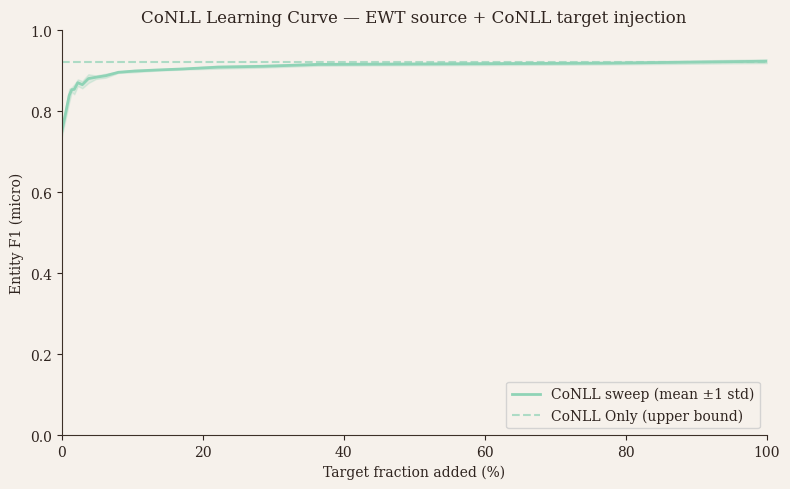

In [16]:
# Plot 1: CoNLL learning curve
subset = conll_df[conll_df["eval_set"] == "conll_test"]
grouped = subset.groupby("target_pct")[F1_COL].agg(["mean", "std"]).reset_index()

ub_conll = baseline_mean(BASE_CONLL, "conll_test")

fig, ax = plt.subplots(figsize=(8, 5), facecolor=BG)
ax.set_facecolor(BG)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

color = DOMAIN_COLORS["CONLL"]
ax.plot(grouped["target_pct"], grouped["mean"], color=color, linewidth=2, label="CoNLL sweep (mean ±1 std)")
ax.fill_between(
    grouped["target_pct"],
    grouped["mean"] - grouped["std"],
    grouped["mean"] + grouped["std"],
    color=color, alpha=0.25
)
ax.axhline(ub_conll, color=color, linestyle="--", alpha=0.7, label="CoNLL Only (upper bound)")

ax.set_xlim(0, 100)
ax.set_ylim(0, 1)
ax.set_xlabel("Target fraction added (%)")
ax.set_ylabel("Entity F1 (micro)")
ax.set_title("CoNLL Learning Curve — EWT source + CoNLL target injection")
ax.legend(loc="lower right")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "conll_learning_curve.png", dpi=300, bbox_inches="tight")
plt.show()

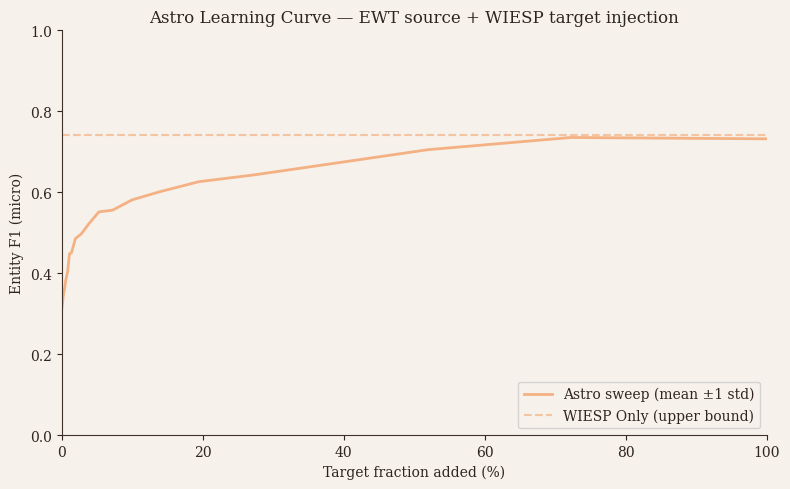

In [17]:
# Plot 2: Astro learning curve
subset = astro_df[astro_df["eval_set"] == "astro_test"]
grouped = subset.groupby("target_pct")[F1_COL].agg(["mean", "std"]).reset_index()

ub_astro = baseline_mean(BASE_ASTRO, "astro_test")

fig, ax = plt.subplots(figsize=(8, 5), facecolor=BG)
ax.set_facecolor(BG)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

color = DOMAIN_COLORS["WIESP"]
ax.plot(grouped["target_pct"], grouped["mean"], color=color, linewidth=2, label="Astro sweep (mean ±1 std)")
ax.fill_between(
    grouped["target_pct"],
    grouped["mean"] - grouped["std"],
    grouped["mean"] + grouped["std"],
    color=color, alpha=0.25
)
ax.axhline(ub_astro, color=color, linestyle="--", alpha=0.7, label="WIESP Only (upper bound)")

ax.set_xlim(0, 100)
ax.set_ylim(0, 1)
ax.set_xlabel("Target fraction added (%)")
ax.set_ylabel("Entity F1 (micro)")
ax.set_title("Astro Learning Curve — EWT source + WIESP target injection")
ax.legend(loc="lower right")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "astro_learning_curve.png", dpi=300, bbox_inches="tight")
plt.show()

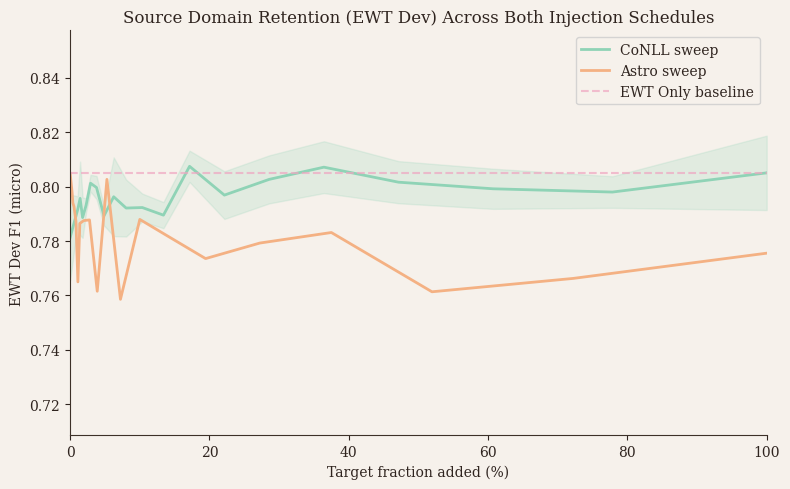

In [18]:
# Plot 3: EWT source retention
conll_ewt = conll_df[conll_df["eval_set"] == "ewt_dev"].groupby("target_pct")[F1_COL].agg(["mean", "std"]).reset_index()
astro_ewt = astro_df[astro_df["eval_set"] == "ewt_dev"].groupby("target_pct")[F1_COL].agg(["mean", "std"]).reset_index()

ub_ewt = baseline_mean(RUNS_DIR / "baselines" / "ewt_only" / "summary.csv", "ewt_dev")

all_means = pd.concat([conll_ewt["mean"], astro_ewt["mean"]])
y_min = all_means.min() - 0.05
y_max = all_means.max() + 0.05

fig, ax = plt.subplots(figsize=(8, 5), facecolor=BG)
ax.set_facecolor(BG)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

conll_color = DOMAIN_COLORS["CONLL"]
wiesp_color = DOMAIN_COLORS["WIESP"]
ewt_color   = DOMAIN_COLORS["EWT"]

ax.plot(conll_ewt["target_pct"], conll_ewt["mean"], color=conll_color, linewidth=2, label="CoNLL sweep")
ax.fill_between(
    conll_ewt["target_pct"],
    conll_ewt["mean"] - conll_ewt["std"],
    conll_ewt["mean"] + conll_ewt["std"],
    color=conll_color, alpha=0.2
)

ax.plot(astro_ewt["target_pct"], astro_ewt["mean"], color=wiesp_color, linewidth=2, label="Astro sweep")
ax.fill_between(
    astro_ewt["target_pct"],
    astro_ewt["mean"] - astro_ewt["std"],
    astro_ewt["mean"] + astro_ewt["std"],
    color=wiesp_color, alpha=0.2
)

ax.axhline(ub_ewt, color=ewt_color, linestyle="--", alpha=0.7, label="EWT Only baseline")

ax.set_xlim(0, 100)
ax.set_ylim(y_min, y_max)
ax.set_xlabel("Target fraction added (%)")
ax.set_ylabel("EWT Dev F1 (micro)")
ax.set_title("Source Domain Retention (EWT Dev) Across Both Injection Schedules")
ax.legend(loc="upper right")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "ewt_retention.png", dpi=300, bbox_inches="tight")
plt.show()

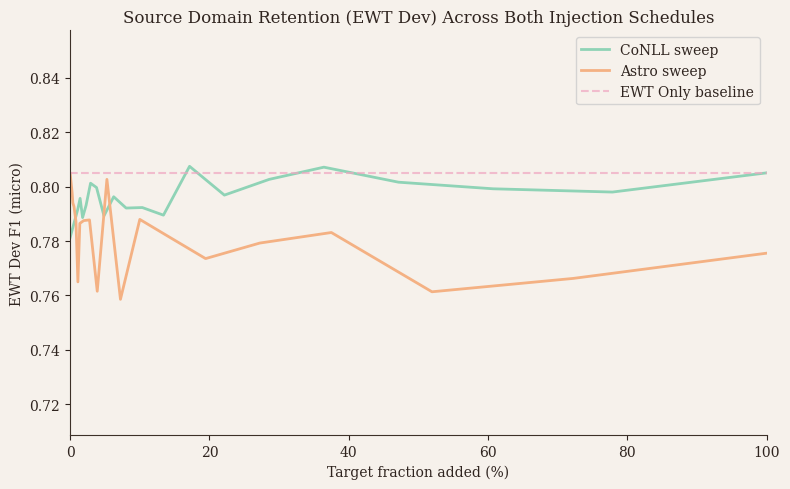

In [19]:
# Plot 3: EWT source retention
conll_ewt = conll_df[conll_df["eval_set"] == "ewt_dev"].groupby("target_pct")[F1_COL].agg(["mean", "std"]).reset_index()
astro_ewt = astro_df[astro_df["eval_set"] == "ewt_dev"].groupby("target_pct")[F1_COL].agg(["mean", "std"]).reset_index()

ub_ewt = baseline_mean(RUNS_DIR / "baselines" / "ewt_only" / "summary.csv", "ewt_dev")

all_means = pd.concat([conll_ewt["mean"], astro_ewt["mean"]])
y_min = all_means.min() - 0.05
y_max = all_means.max() + 0.05

fig, ax = plt.subplots(figsize=(8, 5), facecolor=BG)
ax.set_facecolor(BG)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

conll_color = DOMAIN_COLORS["CONLL"]
wiesp_color = DOMAIN_COLORS["WIESP"]
ewt_color   = DOMAIN_COLORS["EWT"]

# CoNLL sweep - Mean ONLY (fill_between removed)
ax.plot(conll_ewt["target_pct"], conll_ewt["mean"], color=conll_color, linewidth=2, label="CoNLL sweep")

# Astro sweep - Mean and standard deviation shading
ax.plot(astro_ewt["target_pct"], astro_ewt["mean"], color=wiesp_color, linewidth=2, label="Astro sweep")
ax.fill_between(
    astro_ewt["target_pct"],
    astro_ewt["mean"] - astro_ewt["std"],
    astro_ewt["mean"] + astro_ewt["std"],
    color=wiesp_color, alpha=0.2
)

ax.axhline(ub_ewt, color=ewt_color, linestyle="--", alpha=0.7, label="EWT Only baseline")

ax.set_xlim(0, 100)
ax.set_ylim(y_min, y_max)
ax.set_xlabel("Target fraction added (%)")
ax.set_ylabel("EWT Dev F1 (micro)")
ax.set_title("Source Domain Retention (EWT Dev) Across Both Injection Schedules")
ax.legend(loc="upper right")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "ewt_retention.png", dpi=300, bbox_inches="tight")
plt.show()